In [1]:
import uproot
import hist
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np
from matplotlib.lines import Line2D
import ROOT
plt.style.use(hep.styles.CMS)

In [2]:
histos_zp_v1 = uproot.open("histograms/histograms_zp_v1.root")
histos_zp_v1p2 = uproot.open("histograms/histograms_zp_v1p2.root")

zp_v1_nevents = 98000
zp_v1p2_nevents = 98000

In [3]:
#plot of number of shower per event per version
nshowers_v1 = sum([histos_zp_v1[key].to_hist() for key in histos_zp_v1.keys() if "nshowers" in key and not "noSL2" in key])
nshowers_v1p2 = sum([histos_zp_v1p2[key].to_hist() for key in histos_zp_v1p2.keys() if "nshowers" in key and not "noSL2" in key])
nshowers_v1p2_noSL2 = sum([histos_zp_v1p2[key].to_hist() for key in histos_zp_v1p2.keys() if "nshowers" in key and "noSL2" in key])

In [4]:
max_val = max(nshowers_v1.view())
nshowers_v1 = nshowers_v1 * 1/max_val
nshowers_v1p2 = nshowers_v1p2 * 1/max_val
nshowers_v1p2_noSL2 = nshowers_v1p2_noSL2 * 1/max_val

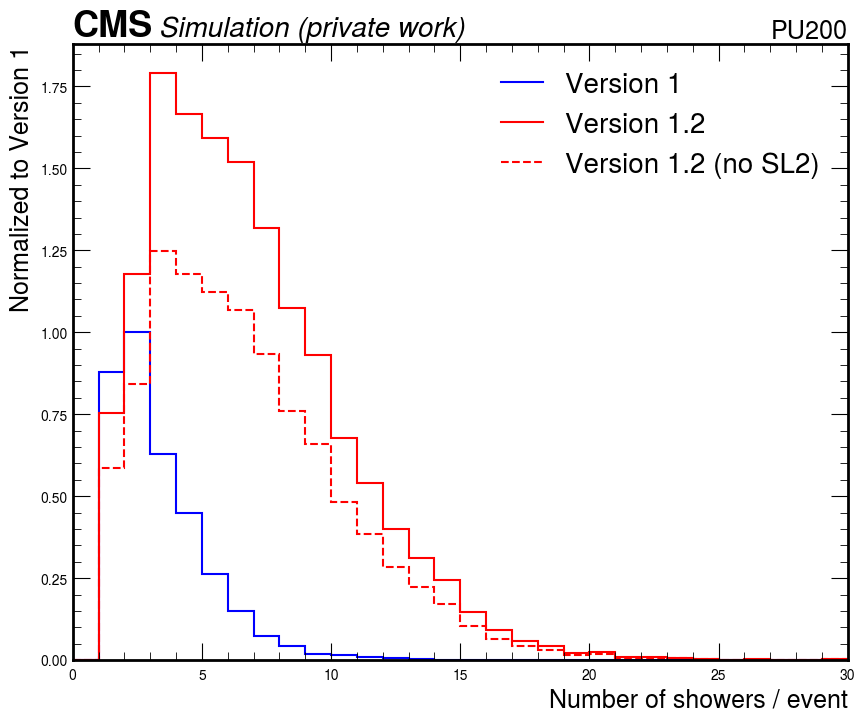

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

nshowers_v1.plot(ax=ax, label='Version 1', color='blue')
nshowers_v1p2.plot(ax=ax, label='Version 1.2', color='red')
nshowers_v1p2_noSL2.plot(ax=ax, label='Version 1.2 (no SL2)', color='red', linestyle='dashed')
ax.set_xlim(0, 30)
ax.tick_params(axis="both", labelsize=10)
ax.set_xlabel("Number of showers / event", fontsize=18)
ax.set_ylabel("Normalized to Version 1", fontsize=18)

hep.cms.label(ax=ax, text="(private work)", data=False, rlabel="PU200", fontsize=20)
ax.legend(fontsize=20)
plt.show()

In [6]:
#plot the shower Bx distribution per version
showers_bx_v1 = sum([histos_zp_v1[key].to_hist() for key in histos_zp_v1.keys() if "showerBx" in key])
# showers_bx_v1 = showers_bx_v1 * 1/sum(showers_bx_v1.view())
showers_bx_v1p2 = sum([histos_zp_v1p2[key].to_hist() for key in histos_zp_v1p2.keys() if "showerBx" in key])
# showers_bx_v1p2 = showers_bx_v1p2 * 1/sum(showers_bx_v1p2.view())

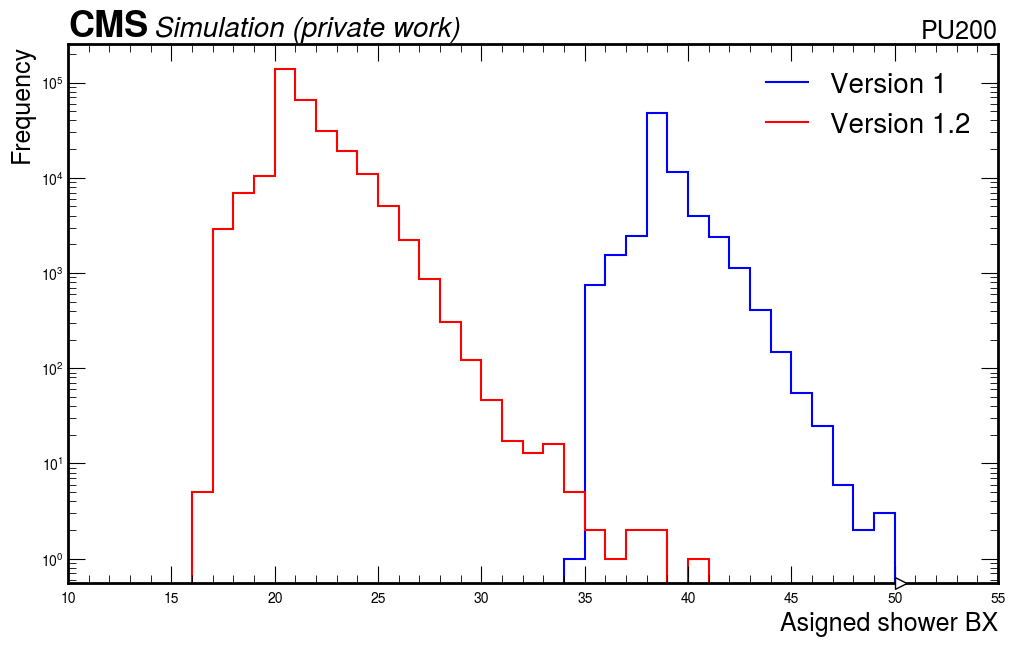

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

showers_bx_v1.plot(ax=ax, label='Version 1', color='blue')
showers_bx_v1p2.plot(ax=ax, label='Version 1.2', color='red')
ax.set_xlim(10, 55)
ax.legend(loc='upper right')
ax.tick_params(axis="both", labelsize=10)
ax.set_xlabel("Asigned shower BX", fontsize=18)
ax.set_yscale("log")
ax.set_ylabel("Frequency", fontsize=18)

hep.cms.label(ax=ax, text="(private work)", data=False, rlabel="PU200", fontsize=20)
ax.legend(fontsize=20)
plt.show()

In [8]:
showers_ndigis_v1 = sum([histos_zp_v1[key].to_hist() for key in histos_zp_v1.keys() if "showerNdigis" in key])
showers_ndigis_v1 = showers_ndigis_v1 * 1/sum(showers_ndigis_v1.view())
showers_ndigis_v1p2 = sum([histos_zp_v1p2[key].to_hist() for key in histos_zp_v1p2.keys() if "showerNdigis" in key ])
showers_ndigis_v1p2 = showers_ndigis_v1p2 * 1/sum(showers_ndigis_v1p2.view())

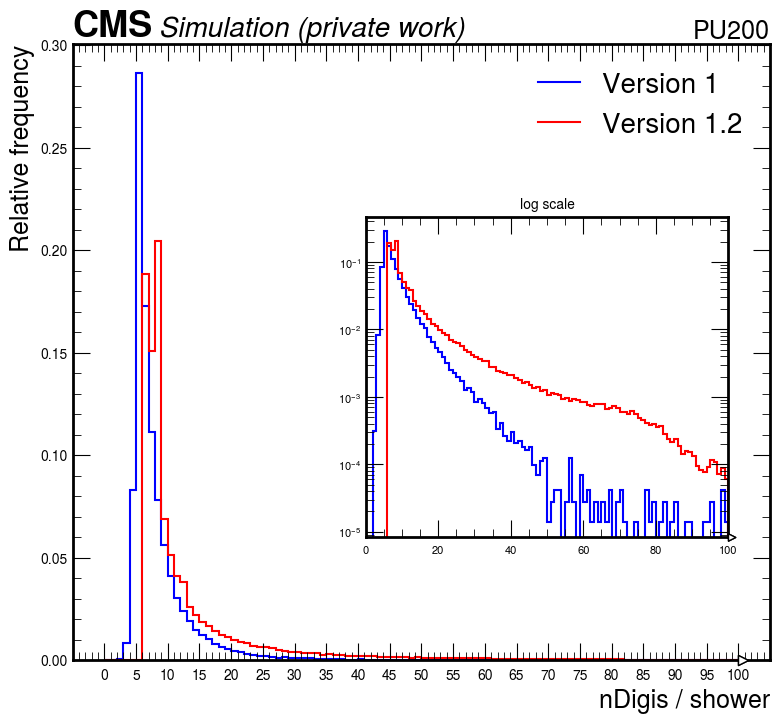

In [9]:
fig, ax = plt.subplots(figsize=(9, 8))

showers_ndigis_v1.plot(ax=ax, label='Version 1', color='blue')
showers_ndigis_v1p2.plot(ax=ax, label='Version 1.2', color='red')
ax.set_xticks(np.arange(0, 101, 5))
ax.tick_params(axis="both", labelsize=10)
ax.set_xlabel("nDigis / shower", fontsize=18)
ax.set_ylabel("Relative frequency", fontsize=18)

# Small inset with log-y version
axins = ax.inset_axes([0.42, 0.2, 0.52, 0.52])  # [x0, y0, width, height] in axis fraction
showers_ndigis_v1.plot(ax=axins, color='blue')
showers_ndigis_v1p2.plot(ax=axins, color='red')
axins.set_yscale("log")
axins.set_xlim(0, 100)
axins.set_xticks(np.arange(0, 101, 20))
axins.tick_params(axis="both", labelsize=8)
axins.set_xlabel("")
axins.set_ylabel("")
axins.set_title("log scale", fontsize=10)

hep.cms.label(ax=ax, text="(private work)", data=False, rlabel="PU200", fontsize=20)
ax.legend(fontsize=20)
plt.show()

In [10]:
showers_size_v1 = sum([histos_zp_v1[key].to_hist() for key in histos_zp_v1.keys() if "showerSize" in key])
showers_size_v1 = showers_size_v1 * 1/sum(showers_size_v1.view())
showers_size_v1p2 = sum([histos_zp_v1p2[key].to_hist() for key in histos_zp_v1p2.keys() if "showerSize" in key ])
showers_size_v1p2 = showers_size_v1p2 * 1/sum(showers_size_v1p2.view())

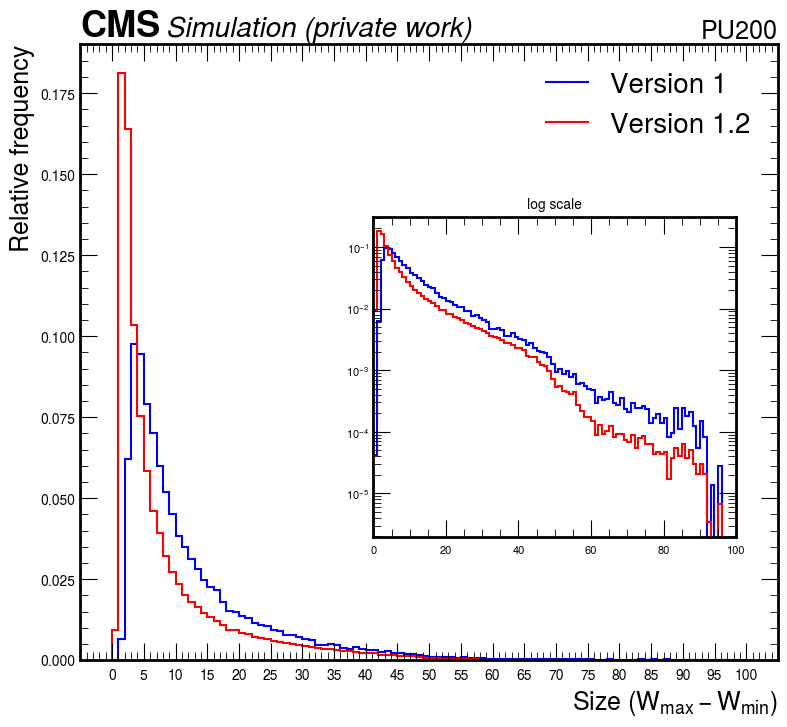

In [11]:
fig, ax = plt.subplots(figsize=(9, 8))

showers_size_v1.plot(ax=ax, label='Version 1', color='blue')
showers_size_v1p2.plot(ax=ax, label='Version 1.2', color='red')
ax.set_xticks(np.arange(0, 101, 5 ))
ax.tick_params(axis="both", labelsize=10)
ax.set_xlabel(r"Size ($W_{max} - W_{min})$", fontsize=18)
ax.set_ylabel("Relative frequency", fontsize=18)

axins = ax.inset_axes([0.42, 0.2, 0.52, 0.52])  # [x0, y0, width, height] in axis fraction
showers_size_v1.plot(ax=axins, color='blue')
showers_size_v1p2.plot(ax=axins, color='red')
axins.set_yscale("log")
axins.set_xlim(0, 100)
axins.set_xticks(np.arange(0, 101, 20))
axins.tick_params(axis="both", labelsize=8)
axins.set_xlabel("")
axins.set_ylabel("")
axins.set_title("log scale", fontsize=10)

hep.cms.label(ax=ax, text="(private work)", data=False, rlabel="PU200", fontsize=20)
ax.legend(fontsize=20)
plt.show()